Columns in data: Index(['SN', 'Total Feedback Given', 'Total Configured', 'Questions',
       'Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4',
       'Weightage 5', 'Average/ Percentage', 'Course Name ', 'Basic Course'],
      dtype='object')
Sample rows:
   SN  Total Feedback Given  Total Configured  \
0   1                     1                12   
1   2                     1                12   
2   3                     1                12   
3   4                     1                12   
4   5                     1                12   

                                           Questions  Weightage 1  \
0  How much of the syllabus was covered in the cl...            0   
1  How well did the teachers prepare for the clas...            0   
2    How well were the teachers able to communicate?            0   
3  The teachers approach to teaching can best be...            0   
4  Fairness of the internal evaluation process by...            0   

   Weightage 2  Weighta

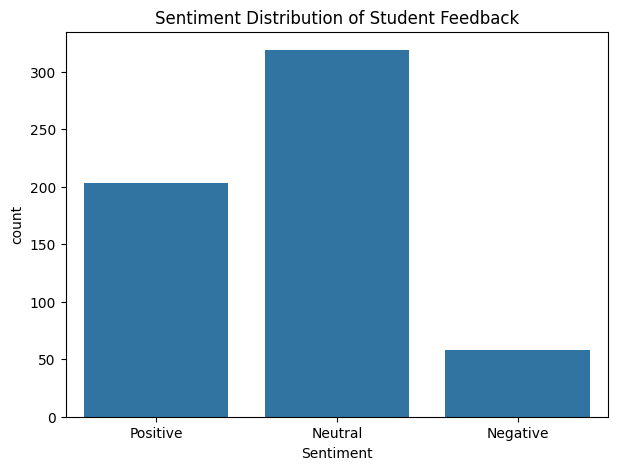

Sentiment Counts:
 Sentiment
Neutral     319
Positive    203
Negative     58
Name: count, dtype: int64

Example Negative Feedback Comments:
1. The institute takes an active interest in promoting internships, student exchange, field visit opportunities for students.
2. Teachers inform you about your expected competencies, course outcomes and program
outcomes.
3. The institute takes an active interest in promoting internships, student exchange, field visit opportunities for students.
4. Teachers inform you about your expected competencies, course outcomes and program
outcomes.
5. The institute takes an active interest in promoting internships, student exchange, field visit opportunities for students.


In [6]:
# Install necessary libraries (run once)
!pip install textblob vaderSentiment

# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Load your file here after upload
file_path = '/content/Student_Satisfaction_Survey.csv'  # Replace with your file path after upload
df = pd.read_csv(file_path, encoding='latin1')  # latin1 to avoid encoding errors

# Show basic info
print("Columns in data:", df.columns)
print("Sample rows:")
print(df.head())

# Clean data - drop rows with missing feedback (assuming feedback column is 'Questions')
df = df.dropna(subset=['Questions'])

# Define simple TextBlob sentiment function
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

# Apply sentiment analysis on the 'Questions' column (replace if your feedback column is different)
df['Sentiment'] = df['Questions'].apply(get_sentiment)

# Show sentiment distribution
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Sentiment', order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution of Student Feedback')
plt.show()

# Print sentiment counts
print("Sentiment Counts:\n", df['Sentiment'].value_counts())

# Display some negative feedback examples for improvement ideas
print("\nExample Negative Feedback Comments:")
for i, comment in enumerate(df[df['Sentiment']=='Negative']['Questions'].head(5), 1):
    print(f"{i}. {comment}")
